# Predictive Health Analytics — Diabetes Prediction Pipeline

**Objective:** Predict whether an adult has diabetes using lifestyle and
demographic features from the 2024 National Health Interview Survey (NHIS).

**Dataset:** `data/adult24.csv` — 32,629 adults surveyed by the CDC.

**Approach:**

1. Load & clean data, audit missingness
2. Screen five candidate chronic diseases → pick diabetes
3. Engineer two feature sets (compact baseline & richer)
4. Train baseline models (Logistic Regression, Random Forest)
5. Train a stronger CatBoost model on the richer features
6. Tune CatBoost hyperparameters with a regularization sweep
7. Compare all models and visualise results


## 0. Environment & paths

Run this notebook from the project root so the package imports resolve.
The data file `data/adult24.csv` must already be present.

In [1]:
# ── Setup: imports and project root ──

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Find the project root so we can import the predictive_health package
ROOT_DIR = Path.cwd()
if (ROOT_DIR / 'predictive_health').exists():
    project_root = ROOT_DIR
elif (ROOT_DIR.parent / 'predictive_health').exists():
    project_root = ROOT_DIR.parent
else:
    raise RuntimeError('Run this notebook from the repo root.')

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 160)
print('Project root:', project_root)


Project root: /home/btwitsvoid/Documents/ML Project/Predictive-Health-Analytics


In [2]:
# ── Load project configuration ──

from predictive_health.config import (
    DATA_PATH, RANDOM_STATE, THRESHOLDS,
    SCREENING_FEATURE_COLS, TARGET_COLS,
)

print('Data file  :', DATA_PATH)
print('Random seed:', RANDOM_STATE)
print('Targets    :', TARGET_COLS)
print('Thresholds :', THRESHOLDS)


Data file  : /home/btwitsvoid/Documents/ML Project/Predictive-Health-Analytics/data/adult24.csv
Random seed: 42
Targets    : ['DIBEV_A', 'PREDIB_A', 'HYPEV_A', 'CHDEV_A', 'PHSTAT_A', 'WTFA_A']
Thresholds : [0.5, 0.4, 0.3]


## 1. Raw data load & top-level audit

We use the same column slice and missing-code map the package uses, so the
notebook matches the pipeline byte-for-byte.

In [3]:
# ── Load the raw survey data for screening ──

from predictive_health.screening import load_screening_frame

screening_df = load_screening_frame()
print(f'Rows: {screening_df.shape[0]:,}  |  Columns: {screening_df.shape[1]}')
screening_df.head()


Rows: 32,629  |  Columns: 17


,FDSCAT3_A,BMICATD_A,DRKSTAT_A,PA18_02R_A,EDUCP_A,SEX_A,AGEP_A,SLPHOURS_A,ECIGEV_A,SMKEV_A,DIBEV_A,PREDIB_A,CHDEV_A,HYPEV_A,PHSTAT_A,WTFA_A,POVRATTC_A
0,1.0,3.0,1.0,3.0,5.0,1.0,49,8.0,2.0,1.0,2.0,2.0,2.0,2.0,1.0,5780.565,2.82
1,1.0,3.0,1.0,1.0,5.0,1.0,53,8.0,2.0,1.0,2.0,2.0,2.0,1.0,2.0,3994.244,2.01
2,1.0,4.0,7.0,1.0,5.0,1.0,82,8.0,2.0,1.0,2.0,2.0,1.0,1.0,2.0,6636.755,1.90
3,1.0,3.0,6.0,2.0,4.0,1.0,42,8.0,2.0,1.0,2.0,2.0,2.0,2.0,3.0,13767.420,4.48
4,1.0,3.0,6.0,3.0,9.0,2.0,38,8.0,2.0,2.0,2.0,2.0,2.0,2.0,3.0,18880.030,6.37


In [4]:
# ── Check how much data is missing in each predictor ──

from predictive_health.screening import selected_feature_missingness

missing_pct = (selected_feature_missingness(screening_df) * 100).round(2)
missing_pct.to_frame('missing %')


,missing %
FDSCAT3_A,4.14
PA18_02R_A,3.66
SLPHOURS_A,3.45
DRKSTAT_A,2.69
ECIGEV_A,2.27
SMKEV_A,2.26
BMICATD_A,1.84
EDUCP_A,0.45
SEX_A,0.02
AGEP_A,0.00


### 1a. Data-hygiene note

NHIS uses special codes in `AGEP_A` (97 = refused, 99 = don't know).
These are not real ages but they slip into the model as if age were 97/99.
The cell below shows this only affects 52 rows (0.16%) — negligible.


In [5]:
# ── Check for NHIS sentinel codes in the age column ──
# NHIS uses 97 = refused, 99 = don't know. These are NOT real ages.
# We check how many rows this affects.

age_raw = pd.read_csv(DATA_PATH, usecols=['AGEP_A', 'DIBEV_A'])
bad_age = age_raw['AGEP_A'].isin([97, 98, 99])

print(f'Rows with sentinel age: {bad_age.sum()} / {len(age_raw)} '
      f'({bad_age.mean()*100:.2f}%)')
print(age_raw.loc[bad_age, 'AGEP_A'].value_counts().sort_index())


Rows with sentinel age: 52 / 32629 (0.16%)
AGEP_A
97    48
99     4
Name: count, dtype: int64


## 1b. Exploratory data analysis

Before choosing a target or training any model, we inspect the feature
distributions and class balance. Three quick checks:

1. **Target class balance** — how imbalanced is diabetes?
2. **Age distribution** by diabetes status — is age a strong separator?
3. **BMI-group prevalence** — do higher BMI categories carry more risk?


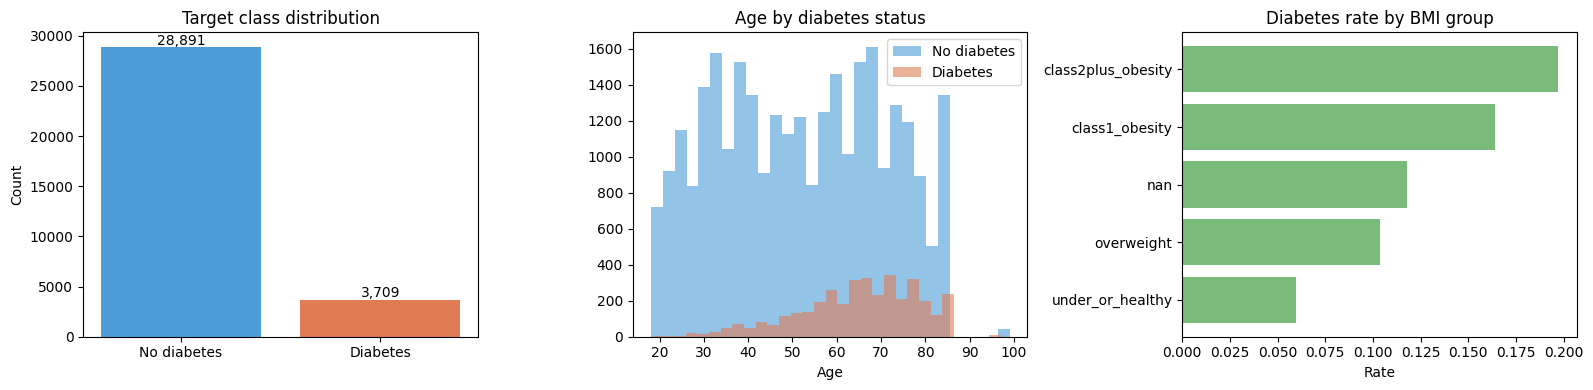

Positive class rate: 11.38%
Class ratio: 7.8 : 1


In [6]:
# ── Exploratory plots: class balance, age, and BMI ──

from predictive_health.etl import build_baseline_diabetes_dataset

eda_df = build_baseline_diabetes_dataset()
target_counts = eda_df['target_diabetes'].value_counts().sort_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Target class balance
axes[0].bar(['No diabetes', 'Diabetes'], target_counts.values,
            color=['#4c9ed9', '#e07b54'])
axes[0].set_title('Target class distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center')

# 2. Age distribution by diabetes status
for label, color in [(0, '#4c9ed9'), (1, '#e07b54')]:
    axes[1].hist(eda_df.loc[eda_df['target_diabetes'] == label, 'age'].dropna(),
                 bins=30, alpha=0.6, color=color,
                 label='Diabetes' if label else 'No diabetes')
axes[1].set_title('Age by diabetes status')
axes[1].set_xlabel('Age')
axes[1].legend()

# 3. Diabetes rate by BMI group
bmi_rate = (eda_df.groupby('bmi_group', dropna=False)['target_diabetes']
            .mean().sort_values())
axes[2].barh(bmi_rate.index.astype(str), bmi_rate.values, color='#7aba7a')
axes[2].set_title('Diabetes rate by BMI group')
axes[2].set_xlabel('Rate')

plt.tight_layout()
plt.show()

print(f'Positive class rate: {eda_df["target_diabetes"].mean():.2%}')
print(f'Class ratio: {target_counts[0.0] / target_counts[1.0]:.1f} : 1')
del eda_df


## 2. Target screening

We screen five candidate chronic-disease targets using a quick logistic
regression under 5-fold stratified CV. Diabetes is chosen because it has
a good balance of moderate class imbalance (~11%) and reasonable
predictability from lifestyle features alone.


In [7]:
# ── Screen 5 candidate targets: which disease is most predictable? ──

from predictive_health.screening import screen_candidate_targets

target_screening = screen_candidate_targets(screening_df).round(4)
target_screening


,target,n,positive_rate,weighted_positive_rate,roc_auc_mean,pr_auc_mean
3,coronary_heart_disease,32516,0.0649,0.0501,0.8258,0.2163
2,hypertension,32577,0.3764,0.3185,0.7990,0.6692
4,fair_or_poor_health,32613,0.1642,0.1484,0.7880,0.4213
0,diabetes,32600,0.1138,0.0999,0.7829,0.2961
1,prediabetes,32572,0.1864,0.1670,0.7424,0.3655


In [8]:
# ── Compare feature sets: demographics-only vs lifestyle-only vs combined ──

from predictive_health.screening import compare_feature_sets

compare_feature_sets(screening_df).round(4)


,target,feature_set,roc_auc_mean,pr_auc_mean
0,hypertension,demographics_only,0.7722,0.6191
1,hypertension,lifestyle_only,0.6828,0.5517
2,hypertension,combined,0.7990,0.6692
3,diabetes,demographics_only,0.7320,0.2194
4,diabetes,lifestyle_only,0.7211,0.2458
5,diabetes,combined,0.7829,0.2961


## 3. Feature engineering (ETL)

Two feature sets are built from the raw NHIS data:

- **Baseline (13 cols):** compact, interpretable — age, sex, BMI, smoking,
  alcohol, activity, sleep, food security, education, poverty ratio
- **Richer (17 cols):** adds region, urban/rural, marital status, detailed
  smoking status, activity guideline combo code

Both share the same target (`target_diabetes`) and explicitly exclude
other health outcomes (prediabetes, hypertension, etc.) to avoid leakage.


In [9]:
# ── Build the two engineered datasets ──

from predictive_health.etl import (
    build_baseline_diabetes_dataset,
    build_richer_diabetes_dataset,
    feature_columns,
    predictor_missingness,
)

baseline_df = build_baseline_diabetes_dataset()   # 11 features
richer_df   = build_richer_diabetes_dataset()      # 15 features

print(f'Baseline: {baseline_df.shape}  |  Positive rate: {baseline_df["target_diabetes"].mean():.4f}')
print(f'Richer  : {richer_df.shape}  |  Positive rate: {richer_df["target_diabetes"].mean():.4f}')

baseline_df.head()


Baseline: (32600, 13)  |  Positive rate: 0.1138
Richer  : (32600, 17)  |  Positive rate: 0.1138


,age,sex,education_group,poverty_group,bmi_group,ever_smoked_100_cigs,ever_used_ecig,alcohol_group,activity_level,sleep_group,food_security,target_diabetes,survey_weight
0,49,male,some_college_or_associate,middle_income,overweight,yes,no,lifetime_abstainer,sufficiently_active,normal_sleep,food_secure,0.0,5780.565
1,53,male,some_college_or_associate,middle_income,overweight,yes,no,lifetime_abstainer,inactive,normal_sleep,food_secure,0.0,3994.244
2,82,male,some_college_or_associate,near_poverty,class1_obesity,yes,no,current_nonheavy,inactive,normal_sleep,food_secure,0.0,6636.755
3,42,male,high_school_or_ged,higher_income,overweight,yes,no,current_nonheavy,insufficiently_active,normal_sleep,food_secure,0.0,13767.420
4,38,female,bachelors_or_higher,higher_income,overweight,no,no,current_nonheavy,sufficiently_active,normal_sleep,food_secure,0.0,18880.030


In [10]:
# ── Missingness in the richer feature set (%) ──

(predictor_missingness(richer_df) * 100).round(2).to_frame('missing %')


,missing %
food_security,4.13
activity_guideline_combo_code,3.91
marital_status,3.66
activity_level,3.64
sleep_group,3.44
alcohol_group,2.66
ever_used_ecig,2.25
smoking_status,2.25
bmi_group,1.82
education_group,0.45


### 3b. Note on survey weights

`survey_weight` (`WTFA_A`) is carried through both datasets but is **not**
passed as `sample_weight` during model training. Why?

- Survey weights are designed for **population-level prevalence estimation**,
  not for optimising predictive accuracy on individual subjects.
- Instead, we use `class_weight='balanced'` (Logistic Regression, Random
  Forest) and `auto_class_weights='Balanced'` (CatBoost), which re-weight
  the loss function by inverse class frequency — a standard approach for
  imbalanced binary classification.
- The survey weight **is** used in the screening stage (`weighted_binary_prevalence`)
  to report population-adjusted prevalence alongside the raw sample rate.


### 3a. Leakage sanity check

No single predictor perfectly separates the target (no group prevalence equals
exactly 0 or 1 on a non-trivial slice). The only flagged rows are the 4 subjects
whose age is the sentinel `99` — handled in section 1a.

In [11]:
# ── Leakage check: does any single feature perfectly predict diabetes? ──

for col in feature_columns(richer_df):
    rates = richer_df.groupby(col, dropna=False)['target_diabetes'].mean()
    perfect = rates[(rates == 0) | (rates == 1)]
    if not perfect.empty:
        print(f'{col} -> {perfect.to_dict()}')

# Expected: only the 4 sentinel-age rows (age=99) and a tiny NaN group.
# No real leakage.


age -> {99: 0.0}
sex -> {nan: 0.0}


## 4. Baseline models

Three models are trained on the **compact baseline** features:

| Model | Purpose |
|---|---|
| DummyClassifier | Sanity check (always predicts majority class) |
| Logistic Regression | Interpretable, `class_weight='balanced'` |
| Random Forest | Non-linear, `class_weight='balanced_subsample'` |

Evaluation: 5-fold stratified CV on training set, then one final test on
a held-out 20% stratified split.


In [12]:
# ── Train baseline models on the compact feature set ──
# Models: DummyClassifier (sanity check), Logistic Regression, Random Forest
# Evaluation: 5-fold stratified CV + 20% stratified hold-out test

from predictive_health.modeling import evaluate_baseline_models

baseline_predictors = feature_columns(baseline_df)
X_baseline = baseline_df[baseline_predictors]
y_baseline = baseline_df['target_diabetes'].astype(int)

metrics_df, fitted_models, X_train_b, y_train_b, X_test_b, y_test_b = \
    evaluate_baseline_models(X_baseline, y_baseline)

metrics_df.round(4)


,model,feature_set,cv_roc_auc,cv_pr_auc,cv_accuracy,cv_f1,test_roc_auc,test_pr_auc,test_accuracy,test_f1
1,logistic_regression,compact_interpretable,0.7815,0.2965,0.6935,0.3527,0.7723,0.2804,0.6870,0.3435
2,random_forest,compact_interpretable,0.7812,0.2902,0.7428,0.3678,0.7681,0.2736,0.7317,0.3558
0,dummy,compact_interpretable,0.5000,0.1138,0.8862,0.0000,0.5000,0.1138,0.8862,0.0000


In [13]:
# ── Overfitting check: how much do CV scores drop on the test set? ──

gap = metrics_df[['model']].copy()
gap['roc_gap'] = (metrics_df['cv_roc_auc'] - metrics_df['test_roc_auc']).round(4)
gap['pr_gap']  = (metrics_df['cv_pr_auc']  - metrics_df['test_pr_auc']).round(4)
gap
# Small positive gaps = healthy. Large gaps = overfitting.


,model,roc_gap,pr_gap
1,logistic_regression,0.0092,0.0160
2,random_forest,0.0131,0.0165
0,dummy,0.0000,-0.0000


### 4a. Logistic regression — what drives predictions?

Two ways to see which features matter:
1. **Coefficients + odds ratios** — from the model weights
2. **Permutation importance** — measured on the test set


In [14]:
# ── Logistic regression coefficients (top 15 by absolute value) ──
# Positive coefficient = higher diabetes risk. Odds ratio > 1 = risk factor.

logistic_model = fitted_models['logistic_regression']
feature_names = logistic_model.named_steps['preprocess'].get_feature_names_out()

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': logistic_model.named_steps['model'].coef_[0],
})
coef_df['odds_ratio'] = np.exp(coef_df['coefficient'])
coef_df.sort_values('coefficient', key=abs, ascending=False).head(15)


,feature,coefficient,odds_ratio
0,num__age,0.912623,2.490848
14,cat__bmi_group_under_or_healthy,-0.827526,0.437129
12,cat__bmi_group_class2plus_obesity,0.707319,2.028545
19,cat__alcohol_group_current_heavier_or_unknown,-0.478999,0.619403
7,cat__poverty_group_below_poverty,0.406028,1.500845
11,cat__bmi_group_class1_obesity,0.361732,1.435814
21,cat__alcohol_group_former_drinker,0.330606,1.391811
8,cat__poverty_group_higher_income,-0.308048,0.734880
25,cat__activity_level_sufficiently_active,-0.258166,0.772467
23,cat__activity_level_inactive,0.244134,1.276516


In [15]:
# ── Permutation importance: which features actually matter for predictions? ──
# Shuffle one feature at a time and measure the drop in ROC-AUC.

from sklearn.inspection import permutation_importance

perm = permutation_importance(
    logistic_model, X_test_b, y_test_b,
    n_repeats=10, random_state=RANDOM_STATE, scoring='roc_auc',
)

pd.DataFrame({
    'feature': X_test_b.columns,
    'importance': perm.importances_mean,
    'std': perm.importances_std,
}).sort_values('importance', ascending=False)


,feature,importance,std
0,age,0.141600,0.006174
4,bmi_group,0.052913,0.004195
3,poverty_group,0.009104,0.002232
8,activity_level,0.008782,0.002168
7,alcohol_group,0.005725,0.001390
1,sex,0.004534,0.000975
10,food_security,0.001869,0.000477
2,education_group,0.001581,0.001168
6,ever_used_ecig,0.000377,0.000242
9,sleep_group,0.000368,0.000864


## 5. CatBoost model (richer features)

CatBoost is a gradient-boosted tree model that handles categorical features
natively — no one-hot encoding needed. We use:

- `depth=6`, `learning_rate=0.03`, `iterations=800` (slow, shallow boosting)
- `auto_class_weights='Balanced'` (handles class imbalance)
- `l2_leaf_reg=3` (default; tuned in Section 6)


In [16]:
# ── Train CatBoost on the richer feature set ──
# CatBoost handles categorical features natively (no one-hot encoding needed).

from predictive_health.modeling import fit_and_evaluate_catboost

richer_predictors = feature_columns(richer_df)
X_richer = richer_df[richer_predictors]
y_richer = richer_df['target_diabetes'].astype(int)

cat_metrics, cat_cv_df, cat_model, X_test_r, y_test_r = \
    fit_and_evaluate_catboost(X_richer, y_richer)

pd.DataFrame([cat_metrics]).round(4)


,model,feature_set,cv_roc_auc,cv_pr_auc,cv_accuracy,cv_f1,test_roc_auc,test_pr_auc,test_accuracy,test_f1
0,catboost_richer,richer_non_leaky,0.7904,0.3042,0.7002,0.3607,0.7777,0.2891,0.6893,0.3544


In [17]:
# ── CatBoost per-fold CV scores (consistency check) ──

cat_cv_df.round(4)


,fold,roc_auc,pr_auc,accuracy,f1
0,1,0.7880,0.2960,0.6911,0.3517
1,2,0.7860,0.2929,0.6986,0.3547
2,3,0.7810,0.3110,0.6906,0.3497
3,4,0.7936,0.2977,0.7157,0.3724
4,5,0.8035,0.3233,0.7048,0.3750


In [18]:
# ── CatBoost feature importance ──

cat_model.get_feature_importance(prettified=True).rename(
    columns={'Feature Id': 'feature', 'Importances': 'importance'}
)


,feature,importance
0,age,31.609886
1,bmi_group,14.355744
2,alcohol_group,6.927337
3,poverty_group,5.905417
4,activity_guideline_combo_code,5.541144
5,region,5.199751
6,activity_level,4.921210
7,sex,4.227604
8,education_group,4.150936
9,urban_rural,3.391545


### 5a. Threshold sweep

With only ~11% positive rate, the default 0.5 threshold misses many
diabetics. Lowering it trades precision for recall — catching more
true cases at the cost of more false positives.


In [19]:
# ── Threshold sweep: trade precision for recall ──
# With ~11% positive rate, lowering the threshold catches more diabetics
# but increases false positives.

from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

probs = cat_model.predict_proba(X_test_r)[:, 1]

rows = []
for t in THRESHOLDS:
    preds = (probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test_r, preds).ravel()
    rows.append({
        'threshold': t,
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
        'precision': precision_score(y_test_r, preds),
        'recall':    recall_score(y_test_r, preds),
        'f1':        f1_score(y_test_r, preds),
    })

pd.DataFrame(rows).round(4)


,threshold,tn,fp,fn,tp,precision,recall,f1
0,0.5,3938,1840,186,556,0.2321,0.7493,0.3544
1,0.4,3340,2438,115,627,0.2046,0.8450,0.3294
2,0.3,2756,3022,77,665,0.1804,0.8962,0.3003


## 6. Hyperparameter tuning

We test 5 CatBoost configurations varying tree depth, learning rate,
iterations, and L2 regularization. Each is evaluated with **3-fold CV
on the training set** — the winner is picked by CV score, not test score,
to avoid optimistic bias.


In [20]:
# ── Define 5 CatBoost configurations to compare ──

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score
from catboost import CatBoostClassifier
from predictive_health.modeling import prepare_catboost_frame

CONFIGS = [
    {'name': 'current_baseline',  'iterations':  800, 'depth': 6, 'learning_rate': 0.03,  'l2_leaf_reg': 3},
    {'name': 'deeper_slower',     'iterations': 1200, 'depth': 8, 'learning_rate': 0.02,  'l2_leaf_reg': 5},
    {'name': 'balanced_medium',   'iterations': 1000, 'depth': 7, 'learning_rate': 0.025, 'l2_leaf_reg': 4},
    {'name': 'shallower_longer',  'iterations': 1500, 'depth': 5, 'learning_rate': 0.015, 'l2_leaf_reg': 6},
    {'name': 'regularized_deep',  'iterations':  900, 'depth': 8, 'learning_rate': 0.03,  'l2_leaf_reg': 8},
]

# Split the richer dataset 80/20 for tuning
X_tr, X_te, y_tr, y_te = train_test_split(
    X_richer, y_richer,
    test_size=0.2, random_state=RANDOM_STATE, stratify=y_richer,
)


In [21]:
# ── Helper: 3-fold CV for a single CatBoost config ──

def cv_catboost(config, X, y):
    """Return mean CV ROC-AUC and PR-AUC for one config."""
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    auc_scores, pr_scores = [], []

    for train_idx, valid_idx in cv.split(X, y):
        # Split
        X_train_fold = X.iloc[train_idx]
        X_valid_fold = X.iloc[valid_idx]
        y_train_fold = y.iloc[train_idx]
        y_valid_fold = y.iloc[valid_idx]

        # Prepare for CatBoost (fill NaN in age, mark categorical NaN as 'missing')
        X_train_prep, cat_cols, age_fill = prepare_catboost_frame(X_train_fold)
        X_valid_prep, _, _               = prepare_catboost_frame(X_valid_fold, age_fill)

        # Train
        model = CatBoostClassifier(
            iterations=config['iterations'],
            depth=config['depth'],
            learning_rate=config['learning_rate'],
            l2_leaf_reg=config['l2_leaf_reg'],
            loss_function='Logloss',
            eval_metric='AUC',
            auto_class_weights='Balanced',
            random_seed=RANDOM_STATE,
            allow_writing_files=False,
            verbose=False,
            cat_features=cat_cols,
        )
        model.fit(X_train_prep, y_train_fold)

        # Score
        probs = model.predict_proba(X_valid_prep)[:, 1]
        auc_scores.append(roc_auc_score(y_valid_fold, probs))
        pr_scores.append(average_precision_score(y_valid_fold, probs))

    return float(np.mean(auc_scores)), float(np.mean(pr_scores))


In [22]:
# ── Run the full tuning sweep (5 configs x 3-fold CV + 1 final fit each) ──
# Takes a few minutes on CPU.

sweep_rows = []

for cfg in CONFIGS:
    # 1) Cross-validate on training set
    cv_roc, cv_pr = cv_catboost(cfg, X_tr, y_tr)

    # 2) Train final model on full training set, score on held-out test
    X_tr_prep, cat_cols, age_fill = prepare_catboost_frame(X_tr)
    X_te_prep, _, _               = prepare_catboost_frame(X_te, age_fill)

    model = CatBoostClassifier(
        iterations=cfg['iterations'],
        depth=cfg['depth'],
        learning_rate=cfg['learning_rate'],
        l2_leaf_reg=cfg['l2_leaf_reg'],
        loss_function='Logloss',
        eval_metric='AUC',
        auto_class_weights='Balanced',
        random_seed=RANDOM_STATE,
        allow_writing_files=False,
        verbose=False,
        cat_features=cat_cols,
    )
    model.fit(X_tr_prep, y_tr)
    probs = model.predict_proba(X_te_prep)[:, 1]

    sweep_rows.append({
        **cfg,
        'cv_roc_auc':      cv_roc,
        'cv_pr_auc':       cv_pr,
        'test_roc_auc':    roc_auc_score(y_te, probs),
        'test_pr_auc':     average_precision_score(y_te, probs),
        'cv_test_roc_gap': cv_roc - roc_auc_score(y_te, probs),
    })

# Sort by CV score (honest selection — not test score)
sweep_df = pd.DataFrame(sweep_rows).sort_values('cv_roc_auc', ascending=False)
sweep_df.round(4)


,name,iterations,depth,learning_rate,l2_leaf_reg,cv_roc_auc,cv_pr_auc,test_roc_auc,test_pr_auc,cv_test_roc_gap
3,shallower_longer,1500,5,0.015,6,0.7892,0.2981,0.7793,0.2878,0.0099
0,current_baseline,800,6,0.030,3,0.7873,0.2952,0.7777,0.2891,0.0097
2,balanced_medium,1000,7,0.025,4,0.7823,0.2892,0.7746,0.2826,0.0077
1,deeper_slower,1200,8,0.020,5,0.7805,0.2859,0.7733,0.2834,0.0072
4,regularized_deep,900,8,0.030,8,0.7802,0.2832,0.7723,0.2801,0.0079


### 6a. Best configuration

The config with the highest **CV ROC-AUC** wins. Its test score is reported
once as an unbiased generalization estimate.


In [23]:
# ── Best config (selected by CV, not by test) ──

winner = sweep_df.iloc[0]
print('Best configuration:', winner['name'])
print(f'  CV ROC-AUC  : {winner["cv_roc_auc"]:.4f}')
print(f'  Test ROC-AUC: {winner["test_roc_auc"]:.4f}')
print(f'  Gap         : {winner["cv_test_roc_gap"]:.4f}  (small = no overfitting)')


Best configuration: shallower_longer
  CV ROC-AUC  : 0.7892
  Test ROC-AUC: 0.7793
  Gap         : 0.0099  (small = no overfitting)


## 7. Final model comparison

All four models side by side. CatBoost with richer features achieves the
highest ROC-AUC, but Logistic Regression is close and fully interpretable.


In [24]:
# ── Final scoreboard: all models compared ──

final = pd.concat([
    metrics_df,
    pd.DataFrame([cat_metrics]),
], ignore_index=True).sort_values('test_roc_auc', ascending=False)

final.round(4)


,model,feature_set,cv_roc_auc,cv_pr_auc,cv_accuracy,cv_f1,test_roc_auc,test_pr_auc,test_accuracy,test_f1
3,catboost_richer,richer_non_leaky,0.7904,0.3042,0.7002,0.3607,0.7777,0.2891,0.6893,0.3544
0,logistic_regression,compact_interpretable,0.7815,0.2965,0.6935,0.3527,0.7723,0.2804,0.6870,0.3435
1,random_forest,compact_interpretable,0.7812,0.2902,0.7428,0.3678,0.7681,0.2736,0.7317,0.3558
2,dummy,compact_interpretable,0.5000,0.1138,0.8862,0.0000,0.5000,0.1138,0.8862,0.0000


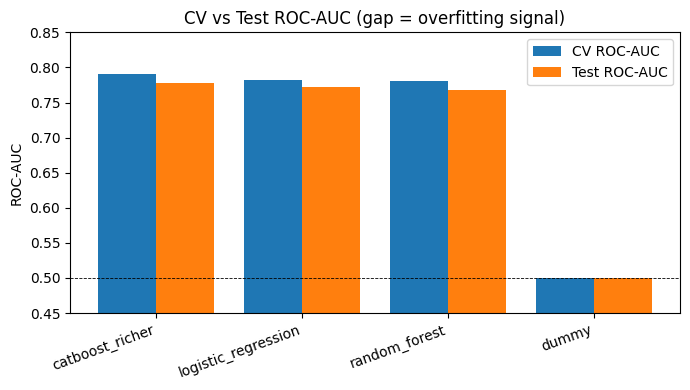

In [25]:
# ── Bar chart: CV vs Test ROC-AUC for every model ──

labels = final['model'].tolist()
cv_vals = final['cv_roc_auc'].astype(float).tolist()
te_vals = final['test_roc_auc'].astype(float).tolist()
x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - 0.2, cv_vals, 0.4, label='CV ROC-AUC')
ax.bar(x + 0.2, te_vals, 0.4, label='Test ROC-AUC')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha='right')
ax.set_ylabel('ROC-AUC')
ax.set_ylim(0.45, 0.85)
ax.axhline(0.5, color='k', ls='--', lw=0.6)
ax.set_title('CV vs Test ROC-AUC (gap = overfitting signal)')
ax.legend()
plt.tight_layout()
plt.show()
